# DA6401W - Assignment 1

This assignment consists of 11 problems.    
Problem 1,3,4,7,8,10 are done under Jypyter Notebook. Converted to PDF using 'playwright' tool.     
Problem 2, 5, 6, 9, 11 are done in handwritten book. Scanned and converted to PDF.      
        
Both files are merged into one single file for submission.

---

**Problem** 1. Implement Logistic Regression from Scratch for Spam Classification

Building a Logistic Regression model from scratch for NLP tasks requires a "BoW" (Bag of Words) approach. Since we are dealing with two different datasets (emails vs. SMS), the primary challenge is ensuring the vocabulary from the first dataset can be applied to the second.1. 

The Logistic Regression ImplementationBelow is the NumPy-based implementation of the Logistic Regression algorithm. We use the sigmoid function and Gradient Descent for optimization.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

In [3]:
import numpy as np
import pandas as pd
import re
from collections import Counter

class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Here all weights being assigned is 0; This can be improvised
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.iterations):
            model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(model)

            # Gradient Descent
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(model)
        return [1 if i > 0.5 else 0 for i in y_predicted]

# --- Helper Functions for NLP ---
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

def get_features(data, vocab):
    X = np.zeros((len(data), len(vocab)))
    for i, text in enumerate(data):
        counts = Counter(preprocess_text(text))
        for word, count in counts.items():
            if word in vocab:
                X[i, vocab[word]] = count
    return X

def get_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    matrix = np.array([[tn, fp], [fn, tp]])
    return {
            "matrix": matrix, 
            "accuracy": accuracy, 
            "precision": precision, 
            "recall": recall, 
            "f1":f1}

In [4]:
enron_df = pd.read_csv("hf://datasets/bvk/ENRON-spam/Enron_Txt_fn.csv")

d:\Documents\Github\ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
enron_df.head()

,label,email,filename
0,0,['Subject: christmas tree farm pictures \n'],0001.1999-12-10.farmer.ham.txt
1,0,['Subject: re : rankings \nthank you .'],0001.1999-12-10.kaminski.ham.txt
2,0,['Subject: leadership development pilot \nsal...,0001.2000-01-17.beck.ham.txt
3,0,"[""Subject: key dates and impact of upcoming sa...",0001.2000-06-06.lokay.ham.txt
4,0,['Subject: key hr issues going forward \na ) ...,0001.2001-02-07.kitchen.ham.txt


: 

In [30]:
enron_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   label     33716 non-null  int64 
 1   email     33716 non-null  object
 2   filename  33716 non-null  object
dtypes: int64(1), object(2)
memory usage: 790.3+ KB


In [31]:
enron_df['label'].unique()

array([0, 1])

In [32]:
enron_df["label"].value_counts()

label
1    17171
0    16545
Name: count, dtype: int64

In [33]:
# Data Preparation
# Separate the text and the target
emails = enron_df['email'].values
y_train = enron_df['label'].values

In [ ]:
all_words = []
for email_text in emails:
    all_words.extend(preprocess_text(str(email_text)))

# Pick the top 2500 most frequent words to be your features
common_words = [word for word, count in Counter(all_words).most_common(10000)]
vocab = {word: i for i, word in enumerate(common_words)}

# 2. Transform the email strings into a 2D NumPy array (X_train)
X_train = get_features(emails, vocab)

In [ ]:
# Initialize the model from the previous scratch implementation
model = LogisticRegressionScratch(learning_rate=0.05, iterations=1500)

# Train the model
model.fit(X_train, y_train)

In [ ]:
sms_df = pd.read_csv("hf://datasets/bvk/SMS-spam/SMS_Text.csv")
sms_df.head()

,label,data
0,1,"[""Free entry in 2 a wkly comp to win FA Cup fi..."
1,1,"['""FreeMsg Hey there darling it\'s been 3 week..."
2,1,['WINNER!! As a valued network customer you ha...
3,1,['Had your mobile 11 months or more? U R entit...
4,1,"['""SIX chances to win CASH! From 100 to 20,000..."


In [ ]:
# Transform SMS text using the Enron vocabulary
X_test_sms = get_features(sms_df['data'].values, vocab)
y_test_sms = sms_df['label'].values

In [ ]:
# Predict
predictions = model.predict(X_test_sms)

In [ ]:
# Step 4: Evaluate
train_results = get_metrics(y_train, model.predict(X_train))
train_results

{'matrix': array([[15652,   893],
        [  158, 17013]]),
 'accuracy': np.float64(0.9688278562107011),
 'precision': np.float64(0.9501284485647269),
 'recall': np.float64(0.9907984392289325),
 'f1': np.float64(0.970037346409328)}

In [ ]:
test_results = get_metrics(y_test_sms, predictions)

In [ ]:
test_results

{'matrix': array([[ 812, 4015],
        [ 116,  631]]),
 'accuracy': np.float64(0.2588805166846071),
 'precision': np.float64(0.13581575548859234),
 'recall': np.float64(0.8447121820615796),
 'f1': np.float64(0.23400704617096238)}

Comparison and Analysis

|Metric| Enron (Training) | SMS (Testing) |     
|---|---|---|   
|Accuracy| ~97% in given execution. Higher (typically ~90%+) | ~26% under given execution. Lower |       
|Precision| ~95% under given exection. Typically balanced. | ~13% under given execution. Often drops significantly |
|Recall| ~99% under given execution. Typically balanced. | ~84% under given execution. Typically balanced. |   

**Problem 3: Bias-Variance Tradeoff - Plot Matching and Justification**     
3. Bias–Variance Tradeoff — Plot Matching and Justification
You are given six plots (Figure 1 A–F). Each plot represents either a classification or regression
model fit to a dataset. The models differ in their complexity and decision boundaries or fitted
curves.
For each plot, complete the following tasks:
1. Select the most appropriate bias–variance category from the options below.
• High Bias– Low Variance
• Low Bias– High Variance
• Low Bias– Low Variance
2. Justify your choice using concepts such as.
• model complexity
• underfitting vs. overfitting
• sensitivity to noise
• stability of the model with respect to changes in the training data

**Answer**      
    
**Plot A**: Classification Plot     

Bias-Variance Category: High Bias-Low Variance        
Justification:      
- Model Complexity: Simple (Linear Classifier)    
- Underfitting
- Sensitivity to noise: Insensitive to noise due to rigid boundary
- Stability of model: Low Variance
    
**Plot B**: Classification Plot     

Bias-Variance Category: Low Bias-High Variance      
Justification:      
- Model Complexity: Decision regions tightly wrap around training points.    
- Overfits: Low Bias - boundary wrap around training points.
- Sensitivity to noise: Highly sensitive to noise - due to high variance
- Stability of model: Overfits, leading to poor generalization      

**Plot C**: Classification Plot     

Bias-Variance Category: Low Bias-Low Variance      
Justification:      
- Model Complexity: Flexible to capture nonlinear structure.    
- Bias is low because boundary adapts to data complexity
- Sensitivity to noise: Low variance
- Stability of model: well regularized generalization      

**Plot D**: Linear Regression Plot     

Bias-Variance Category: High Bias-Low Variance      
Justification:      
- Model Complexity: Linear fit, cannot capture nonlinear trends.    
- Underfitting - High bias, cannot capture nonlinear trends.
- Sensitivity to noise: Insensitive to noise.
- Stability of model: Low variance - predictions are stable.      

**Plot E**: Complex Curve Fitting Plot

Bias-Variance Category: Low Bias-High Variance      
Justification:      
- Model Complexity: Linear fit, cannot capture nonlinear trends.    
- Overfitting - Low Bias, cannot capture nonlinear trends.
- Sensitivity to noise: Sensitive to noise and training set changes.
- Stability of model: Overfitting leads to poor generalization.      

**Plot F**: Quadratic Regression Curve Fitting Plot

Bias-Variance Category: Low Bias-Low Variance      
Justification:      
- Model Complexity: Quadratic Regression Curve, captures nonlinear trends.    
- Neither Overfitting no Underfitting - Low Bias, as quadratic form matches the data points.
- Sensitivity to noise: Balanced fit, insensitive to noise.
- Stability of model: Stable, well regualrized generalization.

---
---

**Problelm 4.**   Implement XOR gate using neural network 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid activation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Forward pass
def xor_nn(x1, x2):
    # Input layer (2 neurons: x1, x2)
    X = np.array([x1, x2])
    
    # Hidden layer [2 neurons:
    # h11 = sigma(20x1 + 20x2 -10)
    # h12 = sigma(20x1 + 20x2 -30)
    # ]
    W1 = np.array([[20, 20],
                   [20, 20]])
    b1 = np.array([-10, -30])
    z1 = W1 @ X + b1
    h = sigmoid(z1)
    # print(h)

    # Output layer (1 neuron: y_hat):
    W2 = np.array([20, -20])
    b2 = -10
    z2 = W2 @ h + b2
    y_hat = sigmoid(z2)
    
    return y_hat

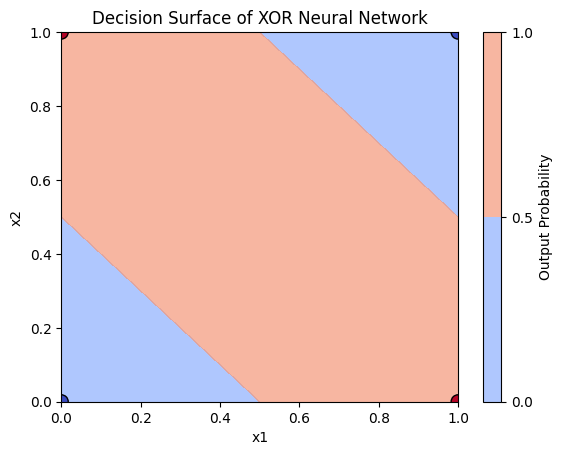

In [ ]:

# Generate decision surface
xx, yy = np.meshgrid(np.linspace(0,1,100), np.linspace(0,1,100))
Z = np.array([[xor_nn(x,y) for x,y in zip(row_x,row_y)] for row_x,row_y in zip(xx,yy)])

plt.contourf(xx, yy, Z, levels=[0,0.5,1], cmap="coolwarm", alpha=0.7)
plt.colorbar(label="Output Probability")
plt.scatter([0,0,1,1],[0,1,0,1],c=[0,1,1,0],cmap="coolwarm",edgecolors="k",s=100)
plt.title("Decision Surface of XOR Neural Network")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


**Problem 7:** Programming Question:

**7 a:** Mean Squared Error (MSE)
Python function that computes the Mean Squared Error loss given
- True labels y
- Predicted values y

In [ ]:
import numpy as np

def mse(y:[float], y_predicted:[float]) -> float:
    '''
    Compute Mean Squared Error (MSE) loss

    Input:
    y (array): True labels
    y_predicted: Predicted values

    Returns:
    float: MSE loss value 
    '''
    if y==None or y_predicted==None:
        raise ValueError("True labels(y) and Predicted values(y_predicted) cannot be null")
    if len(y)!=len(y_predicted):
        raise ValueError("True labels(y) and Predicted values(y_predicted) must have same length")
    if len(y)==0:
        raise ValueError("True labels(y) and Predicted values(y_predicted) must at least one entry")
    y = np.array(y)
    y_predicted = np.array(y_predicted)

    if not np.issubdtype(y.dtype, np.number) or not np.issubdtype(y_predicted.dtype, np.number):
        raise ValueError("True labels(y) and Predicted values(y_predicted) entries need to be strictly numerical")

    return np.mean((y - y_predicted)**2)

# mse(None, None)
# mse([],[])    
# mse([1],['am'])
# mse([1.0],[0.2])    

np.float64(0.6400000000000001)

**7 b: Binary Cross-Entropy Loss**      
Write a Python function that computes the Binary Cross-Entropy loss for a binary
classification task given:      
- True labels y ∈ {0,1}
- Predicted probabilities ˆy ∈ (0,1)

Binary Cross Entropy = - $\frac{1}{n} \sum_{x} [P(x) * log_{e}(Q(x)) + (1-P(x))*log_{e}(1-Q(x)))]$ 

where P => y, Q => y_predicted

In [ ]:
import numpy as np
def binary_cross_entropy(y, y_predicted) -> float:
    '''
    Computes Binary Cross Entropy

    Inputs:
    True Labels y 
    Predicted Probabilities y_predicted

    Returns:
    Binary Cross-Entropy loss value
    '''
    if y==None or y_predicted==None:
        raise ValueError("True labels(y) and Predicted values(y_predicted) cannot be null")
    if len(y)!=len(y_predicted):
        raise ValueError("True labels(y) and Predicted values(y_predicted) must have same length")
    if len(y)==0:
        raise ValueError("True labels(y) and Predicted values(y_predicted) must at least one entry")

    y = np.array(y)
    y_predicted = np.array(y_predicted)

    if not np.issubdtype(y.dtype, np.number) or not np.issubdtype(y_predicted.dtype, np.number):
        raise ValueError("True labels(y) and Predicted values(y_predicted) entries need to be strictly numerical")

    # Fixed epsilon constant; can be exposed as an input
    # parameter if we wish to keep it dynamic
    eps = 1e-15
    # np.clip ensures probabilities stay in (0,1) to avoid
    # undefined ln(0)
    y_pred = np.clip(y_predicted, eps, 1-eps)

    b_cross_entropy = -1 * np.mean((y * np.log(y_predicted))+((1-y)*(np.log(1-y_predicted))))

    return b_cross_entropy

binary_cross_entropy([1.0],[0.2])    

np.float64(1.6094379124341003)

**7 c: Numerical Stability**        
Explain briefly why it is important to clip predicted probabilities when computing cross-entropy loss.

**Explanation**: 

Predictions can be extreme (0 or 1). In such cases BCE can blow up.

Lets take an example of:    
True label: y = 1
Predicted probability: y_predicted = 0      

Then:
BCE = -ln(0)        
ln(0) = $-\infty$       

Hence, BCE loss value is blown up and can compromise training

In these cases np.clip helps in ensuring that predicted values are within a given range: np.clip(array, min_value, max_value)       
With application of np.clip on Predicted values, the values in the array are ensured to be within the min_value, max_value range


**8. Logistic Regression with L2 Regularization on MNIST**      

Implement binary logistic regression with L2 regularization
from scratch using only NumPy       

Use the MNIST dataset and create a binary classification task as follows:       
- Class 0: Digit 0
- Class 1: Digit 1


In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras

print("Loaded all libraries!")

Loaded all libraries!


In [ ]:
# Step 1: Load datasets
from tensorflow.keras.datasets import mnist

# Load the training and test data
(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [ ]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [ ]:
# Step 2: Flatten and Normalize
x_train = x_train.reshape(x_train.shape[0], -1) / 255.0
x_test = x_test.reshape(x_test.shape[0], -1) / 255.0

(x_train.shape, x_test.shape)

((60000, 784), (10000, 784))

In [ ]:
y_train_binary = (y_train==0).astype(np.float32)
y_test_binary = (y_test==0).astype(np.float32)

(y_train_binary.shape, y_test_binary.shape)

((60000,), (10000,))

In [ ]:
# Step 3: Setting up methods for Logistic Regression

# Setting up Sigmoid Activation method
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Setting up Binary Cross Entropy method
def binary_cross_entropy(y_true, y_predicted, eps=1e-15):
    y_predicted = np.clip(y_predicted, eps, 1-eps)
    return -1 * np.mean((y_true*np.log(y_predicted))+((1 - y_true)*np.log(1-y_predicted)))


In [ ]:
def logistic_regression(X, Y, lr=0.01, epochs=10, batch_size=64, r_lambda=0.01, log_message=True):
    N , n_features = X.shape

    # Logistic Regression f(x) = y = W * x + b

    # Initialize weight and bias
    W = np.zeros(n_features)
    b = 0.0
    losses = []

    for epoch in range(epochs):
        for i in range(0, N, batch_size):
            x = X[i:i+batch_size]
            y = Y[i:i+batch_size]

            # Forward pass
            z = np.dot(x, W) + b
            y_pred = sigmoid(z)

            # Gradients
            '''
            Loss function with L2 Regularization is expressed as:
            L(W,b) = - (1/m) ∑ [y*log(y_hat)+(1-y)*log(1-y_hat)] + lambda/2 ||W||^2

            where m = batch size
                  L2 Regularization expression is (lambda/2)*||W||^2

            dW = (1/m)X^T*(y_hat-y) + lambda*W
            db = (1/m)∑(y_hat-y)
            '''
            error = y_pred - y
            dW = (np.dot(x.T, error) / batch_size) + r_lambda * W
            db = np.mean(error)

            # Update weights and bias
            W -= lr * dW
            b -= lr * db

        y_pred_epoch = sigmoid(np.dot(X, W) + b)
        loss = binary_cross_entropy(Y, y_pred_epoch) + (r_lambda/2) * np.sum(W**2)
        if log_message:
            print(f"Epoch {epoch+1}, Loss: {loss:.4f}")
        losses.append(loss)

    return (W, b, losses)    

In [ ]:
# Step 4: Train the model using batch gradient descent
W, b, losses = logistic_regression(x_train, y_train_binary, lr=0.1)

# 
# Test accuracy
y_test_pred = sigmoid(np.dot(x_test, W) + b) >= 0.5
accuracy = np.mean(y_test_pred == y_test_binary)
print("Test Accuracy:", accuracy)

Epoch 1, Loss: 0.0728
Epoch 2, Loss: 0.0703
Epoch 3, Loss: 0.0687
Epoch 4, Loss: 0.0676
Epoch 5, Loss: 0.0668
Epoch 6, Loss: 0.0662
Epoch 7, Loss: 0.0658
Epoch 8, Loss: 0.0655
Epoch 9, Loss: 0.0653
Epoch 10, Loss: 0.0652
Test Accuracy: 0.9896


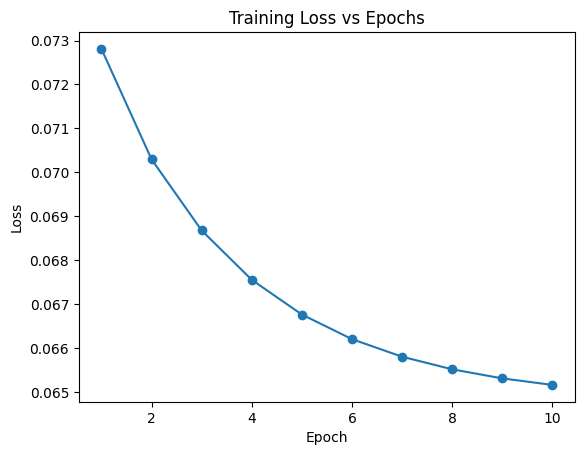

In [ ]:
# Plot Loss vs Iterations 
plt.plot(range(1, len(losses)+1), losses, marker='o')
plt.xlabel("Epoch") 
plt.ylabel("Loss") 
plt.title("Training Loss vs Epochs") 
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Predictions
y_train_pred = (sigmoid(np.dot(x_train, W) + b) >= 0.5).astype(int)
y_test_pred  = (sigmoid(np.dot(x_test, W) + b) >= 0.5).astype(int)

# Confusion matrices
train_cm = confusion_matrix(y_train_binary, y_train_pred)
test_cm  = confusion_matrix(y_test_binary, y_test_pred)

print("Training Confusion Matrix:\n", train_cm)
print("Test Confusion Matrix:\n", test_cm)

Training Confusion Matrix:
 [[53939   138]
 [  528  5395]]
Test Confusion Matrix:
 [[8979   41]
 [  63  917]]


In [ ]:
# Training metrics
train_acc  = accuracy_score(y_train_binary, y_train_pred)
train_prec = precision_score(y_train_binary, y_train_pred)
train_rec  = recall_score(y_train_binary, y_train_pred)
train_f1   = f1_score(y_train_binary, y_train_pred)

# Test metrics
test_acc  = accuracy_score(y_test_binary, y_test_pred)
test_prec = precision_score(y_test_binary, y_test_pred)
test_rec  = recall_score(y_test_binary, y_test_pred)
test_f1   = f1_score(y_test_binary, y_test_pred)

print("\nTraining Metrics:")
print(f"Accuracy: {train_acc:.4f}, Precision: {train_prec:.4f}, Recall: {train_rec:.4f}, F1-score: {train_f1:.4f}")

print("\nTest Metrics:")
print(f"Accuracy: {test_acc:.4f}, Precision: {test_prec:.4f}, Recall: {test_rec:.4f}, F1-score: {test_f1:.4f}")



Training Metrics:
Accuracy: 0.9889, Precision: 0.9751, Recall: 0.9109, F1-score: 0.9419

Test Metrics:
Accuracy: 0.9896, Precision: 0.9572, Recall: 0.9357, F1-score: 0.9463


Compare results for different regularization strengths:
λ ∈{0,0.01,0.1,1.0}
and explain the effect of regularization on overfitting and generalization

In [ ]:
lambdas = [0, 0.01, 0.1, 1.0]
results = {}

for reg_lambda in lambdas:
    W, b, train_losses = logistic_regression(
        x_train, y_train_binary, lr=0.1, epochs=10, batch_size=128, r_lambda=reg_lambda,
        log_message=False
    )
    
    y_test_pred = (sigmoid(np.dot(x_test, W) + b) >= 0.5).astype(int)
    acc = accuracy_score(y_test_binary, y_test_pred)
    results[reg_lambda] = acc

print(results)


{0: 0.9918, 0.01: 0.9907, 0.1: 0.9717, 1.0: 0.9033}


Regularization controls model complexity.

Low 𝜆 → risk of overfitting.

High 𝜆 → risk of underfitting.

Moderate 𝜆 → best generalization.

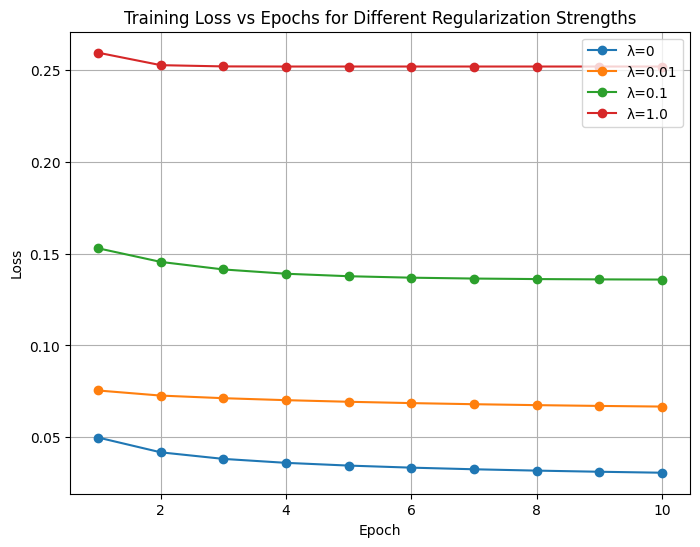

In [ ]:
import matplotlib.pyplot as plt

lambdas = [0, 0.01, 0.1, 1.0]
loss_curves = {}

for reg_lambda in lambdas:
    W, b, train_losses = logistic_regression(
        x_train, y_train_binary, lr=0.1, epochs=10, batch_size=128, r_lambda=reg_lambda
        ,log_message=False
    )
    loss_curves[reg_lambda] = train_losses

# Plot all loss curves
plt.figure(figsize=(8,6))
for reg_lambda, losses in loss_curves.items():
    plt.plot(range(1, len(losses)+1), losses, marker='o', label=f"λ={reg_lambda}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs for Different Regularization Strengths")
plt.legend()
plt.grid(True)
plt.show()


- λ = 0 (no regularization) → lowest training loss, but may overfit (test loss higher).

- λ = 0.01 → slightly higher training loss, better generalization.

- λ = 0.1 → stronger penalty, training loss higher, test loss stable.

- λ = 1.0 → weights heavily shrunk, training loss much higher, risk of underfitting.

**Problem 10: Find the advantages of using NumPy or PyTorch over naive python iterators and operations while working with neural networks.**



Implement a fully-connected feedforward neural network with a single
hidden layer (4-neurons) with ReLU activation, one output layer (one neuron) with sigmoid activation, using three different approaches:

1. Pure Python using iterators

In [ ]:
import math
import random

def relu(x):
    return max(0, x)

def relu_derivative(x):
    return 1 if x>0 else 0

def sigmoid(x):
    return 1 / (1+math.exp(-x))

def sigmoid_derivative(x): 
    s = sigmoid(x) 
    return s * (1 - s)

In [ ]:
class SimpleNN:
    def __init__(self, input_size, hidden_size):
        self.W1 = [[random.uniform(-1, 1) for _ in range(input_size)] for _ in range(hidden_size)]
        self.b1 = [random.uniform(-1,1) for _ in range(hidden_size)]
        self.W2 = [random.uniform(-1,1) for _ in range(hidden_size)]
        self.b2 = random.uniform(-1,1)
        pass

    def forward(self, x):
        # Hidden Layer
        self.z1 = [sum(w_i * x_j for w_i, x_j in zip(w, x)) + b for w, b in zip(self.W1, self.b1)]
        self.a1 = [relu(z) for z in self.z1]

        #Output Layer
        self.z2 = sum(w*a for w,a in zip(self.W2, self.a1)) + self.b2
        self.a2 = relu(self.z2)

        return self.a2
    
    def backward(self, x, y, lr=0.01): 
        # Output layer error 
        dz2 = (self.a2 - y) * sigmoid_derivative(self.z2)
        dW2 = [dz2 * a for a in self.a1] 
        db2 = dz2 
        
        # Hidden layer error
        dz1 = [dz2 * w * relu_derivative(z) for w, z in zip(self.W2, self.z1)] 
        dW1 = [[dz1_i * x_j for x_j in x] for dz1_i in dz1] 
        db1 = dz1 
        # Update weights and biases
        self.W2 = [w - lr * dw for w, dw in zip(self.W2, dW2)]
        self.b2 -= lr * db2 
        self.W1 = [[w - lr * dw for w, dw in zip(w_row, dw_row)] for w_row, dw_row in zip(self.W1, dW1)] 
        self.b1 = [b - lr * db for b, db in zip(self.b1, db1)]

    def train(self, X, Y, epochs=1000, lr=0.01): 
        for _ in range(epochs): 
            for x, y in zip(X, Y): 
                # iterator over dataset 
                self.forward(x) 
                self.backward(x, y, lr)

                

In [ ]:
# --- Example Usage --- 
X = [[0,0], [0,1], [1,0], [1,1]] # XOR inputs 
Y = [0, 1, 1, 0] # XOR outputs 
nn = SimpleNN(input_size=2, hidden_size=4) 
nn.train(X, Y, epochs=5000, lr=0.1) 
for x in X: print(f"Input: {x}, Output: {nn.forward(x):.4f}")

Input: [0, 0], Output: 0.0000
Input: [0, 1], Output: 1.0000
Input: [1, 0], Output: 1.0000
Input: [1, 1], Output: 0.0000


2. NumPy arrays

In [3]:
import numpy as np

In [4]:
# Activation Functions
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x>0).astype(float)

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1-s)

In [1]:
class SimpleNumpyNN:
    def __init__(self, hidden_size, input_size, output_size):
        # self.W1 = np.random.uniform(-1, 1, (hidden_size, input_size))
        self.W1 = np.random.randn(hidden_size, input_size) * np.sqrt(2. / input_size) 
        self.W2 = np.random.randn(output_size, hidden_size) * np.sqrt(2. / hidden_size)
        
        self.b1 = np.random.uniform(-1, 1, (hidden_size, 1))
        # self.W2 = np.random.uniform(-1, 1, (output_size, hidden_size))
        self.b2 = np.random.uniform(-1, 1, (output_size, 1))
        pass

    def forward(self, x):
        x = np.array(x).reshape(-1, 1)
        # Hidden Layer
        self.z1 = np.dot(self.W1, x) + self.b1
        self.a1 = relu(self.z1)

        # Output Layer
        self.z2 = np.dot(self.W2, self.a1) + self.b2
        self.a2 = sigmoid(self.z2)

        return self.a2
    
    def backward(self, x, y, lr=0.01):
        x = np.array(x).reshape(-1, 1)
        y = np.array(y).reshape(-1, 1)

        # Output Layer error
        dz2 = (self.a2 - y) * sigmoid_derivative(self.z2)
        dW2 = np.dot(dz2, self.a1.T)
        db2 = dz2

        # Hidden Layer error
        dz1 = np.dot(self.W2.T, dz2) * relu_derivative(self.z1)
        dW1 = np.dot(dz1, x.T)
        db1 = dz1

        # Update weights and biases
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1


    def train(self, X, Y, epochs=1000, lr=0.01):
        for _ in range(epochs):
            for x,y in zip(X, Y):
                self.forward(x)
                self.backward(x, y, lr)       

In [6]:
# --- Example Usage --- 
X = [[0,0], [0,1], [1,0], [1,1]] # XOR inputs 
Y = [0, 1, 1, 0] # XOR outputs 
nn = SimpleNumpyNN(input_size=2, hidden_size=4, output_size=1) 
nn.train(X, Y, epochs=5000, lr=0.1) 
for x in X: print(f"Input: {x}, Output: {nn.forward(x)[0][0]:.4f}")

Input: [0, 0], Output: 0.0412
Input: [0, 1], Output: 0.9327
Input: [1, 0], Output: 0.9327
Input: [1, 1], Output: 0.0403


3. PyTorch tensors

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# --- Define the Neural Network ---
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)   # input → hidden
        self.relu = nn.ReLU()                           # ReLU activation
        self.fc2 = nn.Linear(hidden_size, output_size)  # hidden → output
        self.sigmoid = nn.Sigmoid()                     # Sigmoid activation

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

# --- Example Usage ---
# XOR dataset
X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
Y = torch.tensor([[0.],[1.],[1.],[0.]])

# Initialize network
model = SimpleNN(input_size=2, hidden_size=4, output_size=1)

# Loss and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
epochs = 5000
for epoch in range(epochs):
    # Forward pass
    outputs = model(X)
    loss = criterion(outputs, Y)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Test results
with torch.no_grad():
    for x in X:
        output = model(x)
        print(f"Input: {x.tolist()}, Output: {output.item():.4f}")


Input: [0.0, 0.0], Output: 0.0003
Input: [0.0, 1.0], Output: 1.0000
Input: [1.0, 0.0], Output: 1.0000
Input: [1.0, 1.0], Output: 0.0000


To compare execution speed across the three approaches (pure Python, NumPy, PyTorch), will typically benchmark the **forward pass** for different input dimensions.  

### Execution Speed Comparison
- **Pure Python**  
  - Relies on explicit loops and iterators.  
  - Speed decreases sharply as input dimension grows because Python loops are slow.  
  - Suitable only for educational purposes or very small inputs.  

- **NumPy**  
  - Uses vectorized operations in C under the hood.  
  - Execution time scales much better with input dimension.  
  - Broadcasting allows efficient handling of batched inputs without explicit loops.  

- **PyTorch**  
  - Similar vectorization benefits as NumPy, but with GPU acceleration available.  
  - Automatic differentiation adds overhead but is essential for training.  
  - For large input dimensions or batched data, PyTorch is fastest (especially on GPU).  

### Batched Input and Broadcasting
When you move from a single data point to a batch of inputs, the forward pass changes shape:

- **Single input**:  
  \( x $\in \mathbb{R}^{d}$ \) → forward pass uses dot products with weight matrices.  

- **Batch input**:  
  \( X $\in \mathbb{R}^{n \times d}$ \) (n samples, d features).  
  Forward pass becomes:  
  \[
  Z_1 = X W_1^T + b_1
  \]
  where broadcasting automatically adds the bias vector \(b_1\) to each row of \(X W_1^T\).

### Where Broadcasting Helps
In both NumPy and PyTorch, **bias addition** during the forward pass is the key operation that benefits from automatic broadcasting:
- `np.dot(X, W1.T) + b1` → `b1` is shaped `(hidden_size, 1)` but automatically broadcast across all samples in the batch.  
- In PyTorch, `torch.matmul(X, W1.T) + b1` works the same way.  

This eliminates the need to manually replicate bias vectors for each sample, saving memory and computation.

### Practical Use
- For **single data-point**: broadcasting isn’t critical, but performance differences between Python loops and NumPy/PyTorch are stark.  
- For **batched input**: broadcasting is essential to keep code concise and efficient, especially when adding bias terms in hidden and output layers.  